
# IS vs OPAD on draws from an auxiliary distribution $q$

This notebook builds a simple discrete bimodal target distribution $p(x)$ on a one-dimensional state space,
constructs a flatter auxiliary distribution
\[
q(x) \propto p(x)^{1/
ho},
\]
runs local Metropolis--Hastings on both $p$ and $q$, and then compares two ways of approximating $p$ from draws produced by $q$:

1. **Importance Sampling (IS)** with weights proportional to $p(x_i)/q(x_i)$.
2. **OPAD weighting** on the same draws: drop duplicate states and weight the unique visited states proportionally to $p(x)$.

The goal is not to use the main project code, but to test the idea in a very small and transparent setting.


In [3]:

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(suppress=True, precision=4)


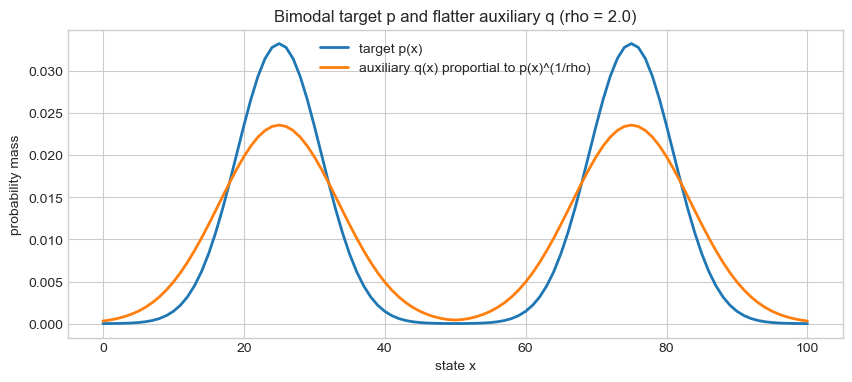

In [4]:

# State space and target / auxiliary distributions.
X = np.arange(101)
sigma = 6.0
rho = 2.0

p_unnorm = np.exp(-0.5 * ((X - 25) / sigma) ** 2) + np.exp(-0.5 * ((X - 75) / sigma) ** 2)
p = p_unnorm / p_unnorm.sum()

q_unnorm = p ** (1.0 / rho)
q = q_unnorm / q_unnorm.sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(X, p, label='target p(x)', lw=2)
ax.plot(X, q, label='auxiliary q(x) proportial to p(x)^(1/rho)', lw=2)
ax.set_xlabel('state x')
ax.set_ylabel('probability mass')
ax.set_title(f'Bimodal target p and flatter auxiliary q (rho = {rho})')
ax.legend();


In [3]:

def mh_sample(target_probs, n_steps, start=0, burn_in=0, thin=1, seed=0):
    """Local random-walk MH on the discrete state space {0, ..., len(target_probs)-1}."""
    rng = np.random.default_rng(seed)
    x = int(start)
    samples = []
    accept_count = 0

    for t in range(n_steps):
        if x == 0:
            proposal = 1
        elif x == len(target_probs) - 1:
            proposal = len(target_probs) - 2
        else:
            proposal = x + (1 if rng.random() < 0.5 else -1)

        accept_prob = min(1.0, target_probs[proposal] / target_probs[x])
        if rng.random() < accept_prob:
            x = proposal
            accept_count += 1

        if t >= burn_in and ((t - burn_in) % thin == 0):
            samples.append(x)

    return np.array(samples, dtype=int), accept_count / n_steps


def count_mode_crossings(samples, threshold=50):
    left_to_right = (samples[:-1] < threshold) & (samples[1:] >= threshold)
    right_to_left = (samples[:-1] >= threshold) & (samples[1:] < threshold)
    return int(np.sum(left_to_right) + np.sum(right_to_left))


Acceptance rate for MH targeting p: 0.931
Acceptance rate for MH targeting q: 0.953
Mode crossings for MH targeting p: 0
Mode crossings for MH targeting q: 29


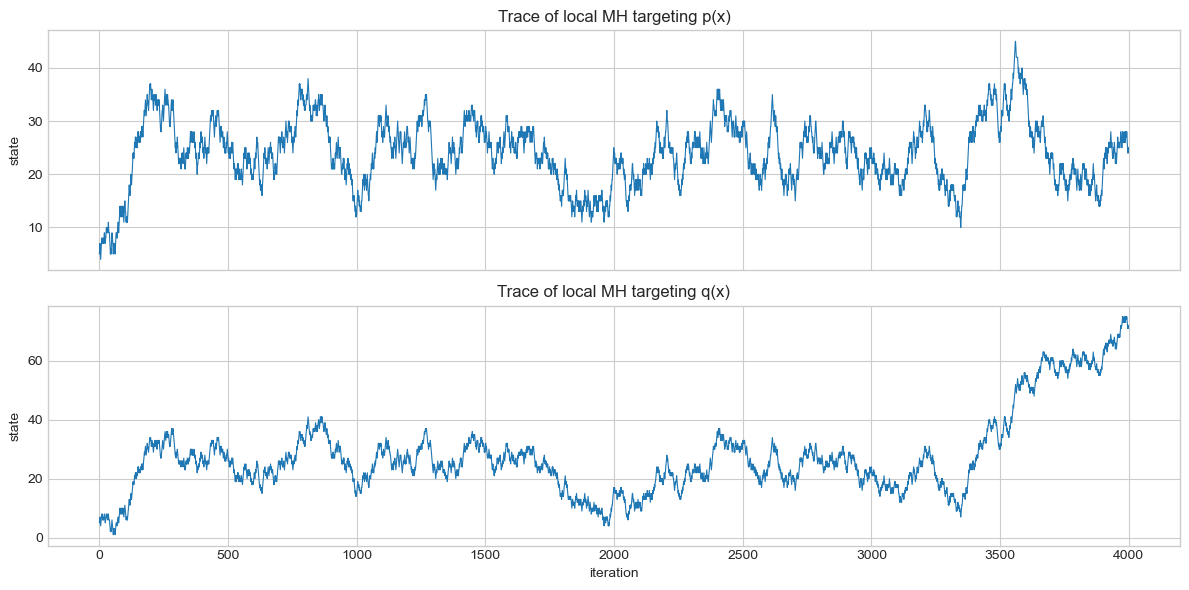

In [4]:

# A long illustrative trace on p and q.
trace_length = 30_000
start_state = 5

samples_p, acc_p = mh_sample(p, trace_length, start=start_state, seed=1)
samples_q, acc_q = mh_sample(q, trace_length, start=start_state, seed=1)

cross_p = count_mode_crossings(samples_p)
cross_q = count_mode_crossings(samples_q)

print(f'Acceptance rate for MH targeting p: {acc_p:.3f}')
print(f'Acceptance rate for MH targeting q: {acc_q:.3f}')
print(f'Mode crossings for MH targeting p: {cross_p}')
print(f'Mode crossings for MH targeting q: {cross_q}')

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(samples_p[:4000], lw=0.8)
axes[0].set_ylabel('state')
axes[0].set_title('Trace of local MH targeting p(x)')
axes[1].plot(samples_q[:4000], lw=0.8)
axes[1].set_ylabel('state')
axes[1].set_xlabel('iteration')
axes[1].set_title('Trace of local MH targeting q(x)')
plt.tight_layout()


In [5]:

def kl_divergence(approx_dist, target_dist):
    mask = approx_dist > 0
    return float(np.sum(approx_dist[mask] * np.log(approx_dist[mask] / target_dist[mask])))


def mse(approx_dist, target_dist):
    return float(np.mean((approx_dist - target_dist) ** 2))


def is_distribution_from_q_draws(samples, p, q, num_states):
    weights = p[samples] / q[samples]
    weights = weights / weights.sum()
    return np.bincount(samples, weights=weights, minlength=num_states)


def opad_distribution_from_draws(samples, p, num_states):
    visited = np.unique(samples)
    approx = np.zeros(num_states)
    approx[visited] = p[visited] / p[visited].sum()
    return approx


Single-chain metrics from q-draws
  IS   : KL(approx || p) = 0.5118, MSE = 0.000222
  OPAD : KL(approx || p) = 0.1201, MSE = 0.000020


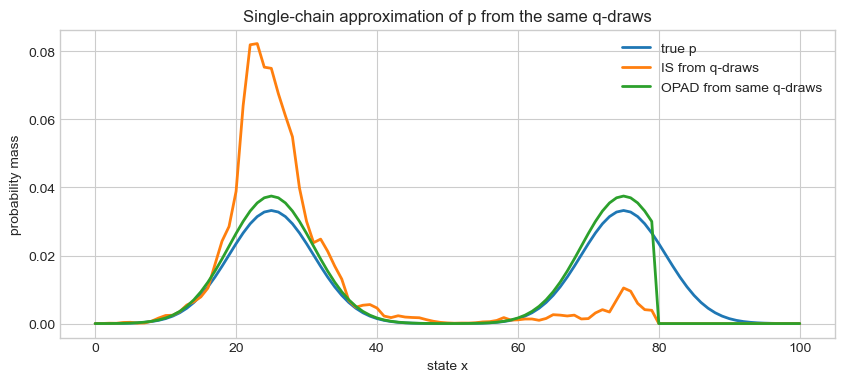

In [6]:

# Single-chain demonstration from q-draws.
num_kept_samples = 1800
single_chain_samples, _ = mh_sample(q, n_steps=num_kept_samples + 500, burn_in=500, start=start_state, seed=7)

is_hat = is_distribution_from_q_draws(single_chain_samples, p, q, len(X))
opad_hat = opad_distribution_from_draws(single_chain_samples, p, len(X))

print('Single-chain metrics from q-draws')
print(f'  IS   : KL(approx || p) = {kl_divergence(is_hat, p):.4f}, MSE = {mse(is_hat, p):.6f}')
print(f'  OPAD : KL(approx || p) = {kl_divergence(opad_hat, p):.4f}, MSE = {mse(opad_hat, p):.6f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(X, p, label='true p', lw=2)
ax.plot(X, is_hat, label='IS from q-draws', lw=2)
ax.plot(X, opad_hat, label='OPAD from same q-draws', lw=2)
ax.set_xlabel('state x')
ax.set_ylabel('probability mass')
ax.set_title('Single-chain approximation of p from the same q-draws')
ax.legend();


In [7]:

# Repeated experiment: compare IS and OPAD from the same q-draws.
chain_lengths = [50, 100, 200, 500, 1000]
num_repetitions = 100
results = []

for N in chain_lengths:
    kl_is_values = []
    kl_opad_values = []
    mse_is_values = []
    mse_opad_values = []

    for seed in range(num_repetitions):
        samples_q_for_comparison, _ = mh_sample(
            q,
            n_steps=N + 500,
            burn_in=500,
            start=start_state,
            seed=seed,
        )

        is_hat = is_distribution_from_q_draws(samples_q_for_comparison, p, q, len(X))
        opad_hat = opad_distribution_from_draws(samples_q_for_comparison, p, len(X))

        kl_is_values.append(kl_divergence(is_hat, p))
        kl_opad_values.append(kl_divergence(opad_hat, p))
        mse_is_values.append(mse(is_hat, p))
        mse_opad_values.append(mse(opad_hat, p))

    results.append({
        'N': N,
        'IS KL mean': np.mean(kl_is_values),
        'OPAD KL mean': np.mean(kl_opad_values),
        'IS MSE mean': np.mean(mse_is_values),
        'OPAD MSE mean': np.mean(mse_opad_values),
    })

for row in results:
    print(row)


{'N': 50, 'IS KL mean': np.float64(2.133149749176711), 'OPAD KL mean': np.float64(1.909185159194217), 'IS MSE mean': np.float64(0.0012323351636774364), 'OPAD MSE mean': np.float64(0.001072076681147285)}
{'N': 100, 'IS KL mean': np.float64(1.7975099327486732), 'OPAD KL mean': np.float64(1.5188417398266636), 'IS MSE mean': np.float64(0.0009107283856199175), 'OPAD MSE mean': np.float64(0.0007752076013103463)}
{'N': 200, 'IS KL mean': np.float64(1.3509980759879832), 'OPAD KL mean': np.float64(1.0445110051162882), 'IS MSE mean': np.float64(0.0006001372090165025), 'OPAD MSE mean': np.float64(0.0004593039124270329)}
{'N': 500, 'IS KL mean': np.float64(1.027052639705271), 'OPAD KL mean': np.float64(0.801780318137446), 'IS MSE mean': np.float64(0.000410807000428452), 'OPAD MSE mean': np.float64(0.00029647227961862506)}
{'N': 1000, 'IS KL mean': np.float64(0.8851817132307661), 'OPAD KL mean': np.float64(0.7280914221693879), 'IS MSE mean': np.float64(0.00033219732279896427), 'OPAD MSE mean': np.f

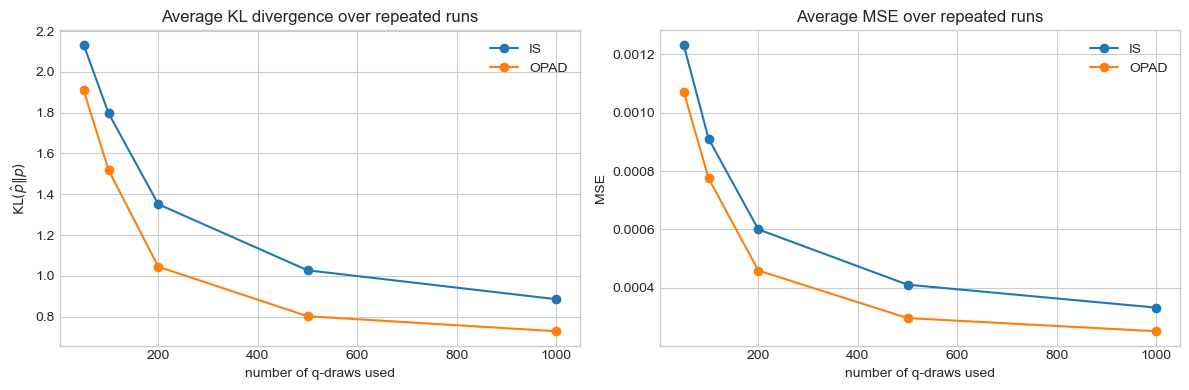

In [8]:

# Plot the repeated-experiment summaries.
Ns = np.array([row['N'] for row in results])
kl_is_means = np.array([row['IS KL mean'] for row in results])
kl_opad_means = np.array([row['OPAD KL mean'] for row in results])
mse_is_means = np.array([row['IS MSE mean'] for row in results])
mse_opad_means = np.array([row['OPAD MSE mean'] for row in results])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(Ns, kl_is_means, marker='o', label='IS')
axes[0].plot(Ns, kl_opad_means, marker='o', label='OPAD')
axes[0].set_xlabel('number of q-draws used')
axes[0].set_ylabel(r'$\mathrm{KL}(\hat p \| p)$')
axes[0].set_title('Average KL divergence over repeated runs')
axes[0].legend()

axes[1].plot(Ns, mse_is_means, marker='o', label='IS')
axes[1].plot(Ns, mse_opad_means, marker='o', label='OPAD')
axes[1].set_xlabel('number of q-draws used')
axes[1].set_ylabel('MSE')
axes[1].set_title('Average MSE over repeated runs')
axes[1].legend()

plt.tight_layout()



## Interpretation

In this setup:

- The target $p(x)$ is bimodal, and a local MH sampler targeting $p$ struggles to cross the low-probability valley.
- The auxiliary distribution $q(x) \propto p(x)^{1/
\rho}$ is flatter, so the same local MH proposal mixes more easily across the two modes.
- Using the same draws from $q$, we can compare two post-processing strategies for approximating $p$:
  - classical importance sampling, which uses the ratio $p(x_i)/q(x_i)$,
  - OPAD weighting, which drops duplicates and renormalizes $p$ over the distinct visited set.

This notebook is deliberately minimal, but it gives a concrete way to test whether the reviewer's suggested comparison is interesting in practice.
